# Brazilian E-Commerce Public Dataset by Olist
https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

# Import libraries

In [1]:
import pandas as pd
from pathlib import Path

# Load data

In [2]:
RAW = Path("../data/raw")

orders = pd.read_csv(
    RAW / "olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)

items = pd.read_csv(RAW / "olist_order_items_dataset.csv")
payments = pd.read_csv(RAW / "olist_order_payments_dataset.csv")

reviews = pd.read_csv(
    RAW / "olist_order_reviews_dataset.csv", parse_dates=["review_creation_date"]
)
products = pd.read_csv(RAW / "olist_products_dataset.csv")
sellers = pd.read_csv(RAW / "olist_sellers_dataset.csv")

customers = pd.read_csv(RAW / "olist_customers_dataset.csv")

for name, df in [
    ("orders", orders),
    ("items", items),
    ("payments", payments),
    ("reviews", reviews),
    ("products", products),
    ("sellers", sellers),
    ("customers", customers),
]:
    print(f"{name:10s}: {df.shape}")

orders    : (99441, 8)
items     : (112650, 7)
payments  : (103886, 5)
reviews   : (99224, 7)
products  : (32951, 9)
sellers   : (3095, 4)
customers : (99441, 5)


# EDA

In [3]:
# Date range
print(orders["order_purchase_timestamp"].agg(["min", "max"]))
print("=" * 50)

# Order status mix
print(orders["order_status"].value_counts())
print("=" * 50)

# Review score distribution and proposed label rate
print(reviews["review_score"].value_counts().sort_index())
print("Label rate (score <= 2):", (reviews["review_score"] <= 2).mean().round(3))
print("=" * 50)

# Grain check
print("Orders with >1 review:", (reviews.groupby("order_id").size() > 1).sum())

min   2016-09-04 21:15:19
max   2018-10-17 17:30:18
Name: order_purchase_timestamp, dtype: datetime64[us]
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64
Label rate (score <= 2): 0.147
Orders with >1 review: 547


# Preprocessing

In [4]:
# Keep the latest review for each order
reviews_dedup = reviews.sort_values("review_creation_date").drop_duplicates(
    "order_id", keep="last"
)
print(reviews_dedup.shape[0], "reviews after deduplication")

98673 reviews after deduplication


In [5]:
# Only delivered orders with a delivery date
df = orders[
    (orders["order_status"] == "delivered")
    & (orders["order_delivered_customer_date"].notna())
].copy()
print(df.shape)

(96470, 8)


In [6]:
# Add review score
df = df.merge(reviews_dedup[["order_id", "review_score"]], on="order_id", how="inner")
print(df.shape)

(95824, 9)


In [7]:
# Add label column (1 if review_score <= 2, else 0)
df["label"] = (df["review_score"] <= 2).astype(int)
df["label"].value_counts()

label
0    83552
1    12272
Name: count, dtype: int64

<Axes: title={'center': 'Total Orders by Month'}, xlabel='Month', ylabel='Total Orders'>

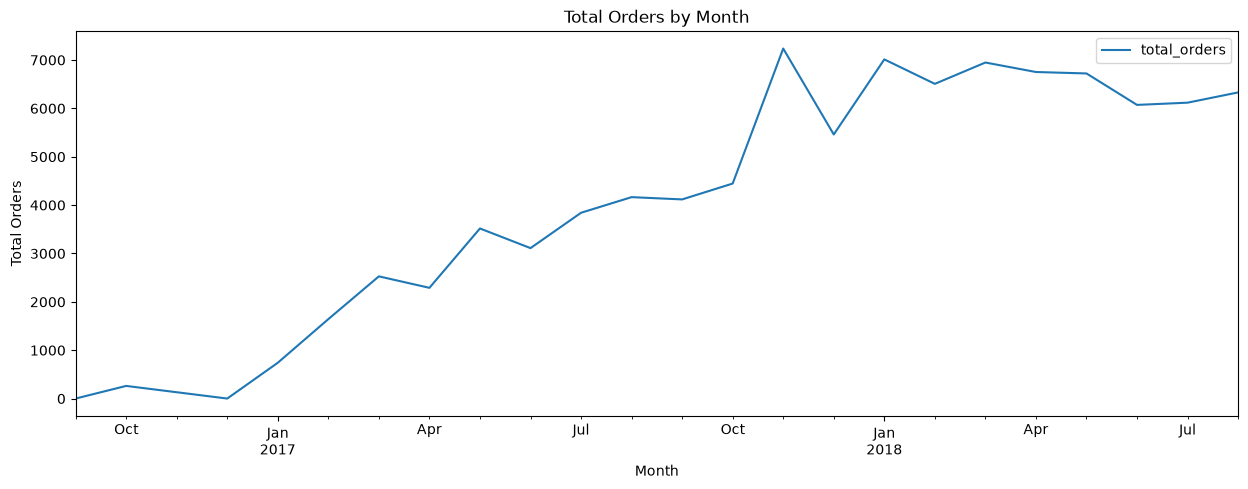

In [8]:
(
    df.groupby(df["order_purchase_timestamp"].dt.to_period("M"))
    .agg(total_orders=("order_id", "count"))
    .plot(
        kind="line",
        figsize=(15, 5),
        title="Total Orders by Month",
        ylabel="Total Orders",
        xlabel="Month",
    )
)

# Feature engineering

In [9]:
# Delivery timing
df["delivery_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days
df["estimated_days"] = (
    df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]
).dt.days
df["delayed_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days
df["is_late"] = (df["delayed_days"] > 0).astype(int)
df["is_late"].value_counts()

is_late
0    89443
1     6381
Name: count, dtype: int64

In [10]:
# Order contents
item_feats = (
    items.merge(products, on="product_id", how="left")
    .groupby("order_id")
    .agg(
        n_items=("order_item_id", "count"),
        n_sellers=("seller_id", "nunique"),
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum"),
        avg_weight_g=("product_weight_g", "mean"),
        main_category=("product_category_name", "first"),
    )
    .reset_index()
)
print(item_feats.shape)

(98666, 7)


In [11]:
# Merge item features into main dataframe
df = df.merge(item_feats, on="order_id", how="left")
df["freight_ratio"] = df["total_freight"] / df["total_price"]
print(df.shape)

(95824, 21)


In [12]:
# Payment features
payment_feats = (
    payments.groupby("order_id")
    .agg(
        payment_type=("payment_type", "first"),
        max_installments=("payment_installments", "max"),
    )
    .reset_index()
)
print(payment_feats.shape)
df = df.merge(payment_feats, on="order_id", how="left")
print(df.shape)

(99440, 3)
(95824, 23)


In [13]:
# Customer location
df = df.merge(
    customers[["customer_id", "customer_state"]], on="customer_id", how="left"
)
print(df.shape)

(95824, 24)


In [14]:
# Trim sparse data in early months
df = df[df["order_purchase_timestamp"] >= "2017-01-01"]
print(df.shape)
print((df["order_purchase_timestamp"].dt.date.agg(["min", "max"])))

(95560, 24)
min    2017-01-05
max    2018-08-29
Name: order_purchase_timestamp, dtype: object


In [15]:
df.groupby(df["order_purchase_timestamp"].dt.to_period("M")).agg(
    total_orders=("order_id", "count")
)

,total_orders
order_purchase_timestamp,
2017-01,741
2017-02,1643
2017-03,2527
2017-04,2290
2017-05,3517
2017-06,3111
2017-07,3842
2017-08,4165
2017-09,4118


# Train/test splits

In [16]:
# Time-based split for modeling
df["split"] = "train"
df.loc[df["order_purchase_timestamp"] >= "2018-04-01", "split"] = "valid"
df.loc[df["order_purchase_timestamp"] >= "2018-06-01", "split"] = "test"

(
    df.groupby("split")
    .agg(total_orders=("order_id", "count"), label_rate=("label", "mean"))
    .loc[["train", "test", "valid"]]
)

,total_orders,label_rate
split,,
train,63566,0.140154
test,18520,0.097300
valid,13474,0.112587


In [17]:
# Late-delivery rate by split
df.groupby("split")["is_late"].mean()

split
test     0.035421
train    0.078470
valid    0.054475
Name: is_late, dtype: float64

In [18]:
# Label rate within late vs on-time orders
df.groupby(["split", "is_late"])["label"].mean().unstack()

is_late,0,1
split,,
test,0.083688,0.467988
train,0.096043,0.658180
valid,0.088462,0.531335


In [19]:
# Monthly trend near the end
(
    df.set_index("order_purchase_timestamp")
    .resample("MS")[["label", "is_late"]]
    .mean()
    .tail(6)
)

,label,is_late
order_purchase_timestamp,,
2018-03-01,0.211860,0.186528
2018-04-01,0.117595,0.043987
2018-05-01,0.107557,0.065010
2018-06-01,0.099802,0.011693
2018-07-01,0.096764,0.032690
2018-08-01,0.095419,0.060821


In [20]:
df[df["is_late"] == 1].groupby("split")["delayed_days"].describe()

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,656.0,6.623476,8.762864,1.0,2.0,4.0,7.0,96.0
train,4988.0,11.342021,15.433048,1.0,3.0,7.0,14.0,188.0
valid,734.0,8.370572,10.373858,1.0,3.0,6.0,10.0,106.0


# Export

In [21]:
keep_cols = [
    "order_id",
    "order_purchase_timestamp",
    "split",
    "label",
    "delivery_days",
    "estimated_days",
    "delayed_days",
    "is_late",
    "n_items",
    "n_sellers",
    "total_price",
    "total_freight",
    "avg_weight_g",
    "main_category",
    "freight_ratio",
    "payment_type",
    "max_installments",
    "customer_state",
]
print("Final dataset shape:", df[keep_cols].shape)

Final dataset shape: (95560, 18)


In [22]:
df[keep_cols].to_parquet("../data/processed/orders_with_features.parquet", index=False)